# TensorFlow API Overview

This notebook is a concise walkthrough of the core TensorFlow and
TensorFlow Probability (TFP) APIs.

**What you will learn:**
- How to create and manipulate `tf.Tensor` objects
- How to build and train a Keras model for regression
- How to work with TFP probability distributions

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import logging

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import tf_keras


_LOG = logging.getLogger(__name__)

2026-03-10 16:28:19.471020: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-10 16:28:19.472829: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 16:28:19.521987: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-03-10 16:28:20.721479: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 16:28:20.721746: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Tensors

A `tf.Tensor` is the fundamental data structure in TensorFlow. It is an
immutable multi-dimensional array, similar to a NumPy array, but designed to
run on CPUs, GPUs, and TPUs.

Key properties:
- `shape`: dimensions of the tensor
- `dtype`: data type (e.g. `float32`, `int32`)
- Supports standard mathematical operations with broadcasting

In [2]:
# Scalar (rank-0 tensor).
scalar = tf.constant(3.14, dtype=tf.float32)
_LOG.info(
    "scalar: %s, shape=%s, dtype=%s", scalar.numpy(), scalar.shape, scalar.dtype
)

# 1-D tensor (vector).
vector = tf.constant([1.0, 2.0, 3.0])
_LOG.info("vector: %s", vector.numpy())

# 2-D tensor (matrix).
matrix = tf.constant([[1, 2], [3, 4]], dtype=tf.float32)
_LOG.info("matrix:\n%s", matrix.numpy())

2026-03-10 16:28:22.579817: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
# Tensor arithmetic (broadcasting and element-wise ops).
a = tf.constant([1.0, 2.0, 3.0])
b = tf.constant([4.0, 5.0, 6.0])
_LOG.info("a + b = %s", (a + b).numpy())
_LOG.info("a * b = %s", (a * b).numpy())
_LOG.info("dot(a, b) = %s", tf.tensordot(a, b, axes=1).numpy())

In [4]:
# Reshaping and transposing.
t = tf.reshape(tf.range(12, dtype=tf.float32), (3, 4))
_LOG.info("original shape: %s", t.shape)
_LOG.info("transposed shape: %s", tf.transpose(t).shape)

## 2. Variables and Gradients

`tf.Variable` wraps a tensor whose value can change (e.g. model weights).
`tf.GradientTape` records operations for automatic differentiation.

In [5]:
# Simple gradient: dy/dx where y = x^2.
x = tf.Variable(3.0)
with tf.GradientTape() as tape:
    y = x**2
dy_dx = tape.gradient(y, x)
_LOG.info("x=%.1f, y=x^2=%.1f, dy/dx=%.1f", x.numpy(), y.numpy(), dy_dx.numpy())

## 3. Keras: Building a Neural Network

Keras is TensorFlow's high-level API for building and training models. A
`Sequential` model stacks layers end-to-end.

**Example:** Fit a simple regression: `y = 2x + 1 + noise`

In [6]:
# Generate synthetic regression data.
np.random.seed(0)
X_train = np.linspace(-3, 3, 200).reshape(-1, 1).astype(np.float32)
y_train = (2 * X_train + 1 + np.random.normal(0, 0.5, X_train.shape)).astype(
    np.float32
)
_LOG.info("X_train shape=%s, y_train shape=%s", X_train.shape, y_train.shape)

In [7]:
# Build a 2-layer network.
model = tf_keras.Sequential(
    [
        # Input layer.
        tf_keras.layers.Dense(16, activation="relu", input_shape=(1,)),
        # Hidden layer.
        tf_keras.layers.Dense(8, activation="relu"),
        # Output: single continuous value.
        tf_keras.layers.Dense(1),
    ]
)
model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 16)                32        


 dense_1 (Dense)             (None, 8)                 136       


 dense_2 (Dense)             (None, 1)                 9         


Total params: 177 (708.00 Byte)


Trainable params: 177 (708.00 Byte)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


In [8]:
# Train for 50 epochs.
history = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
_LOG.info("Final training loss: %.4f", history.history["loss"][-1])

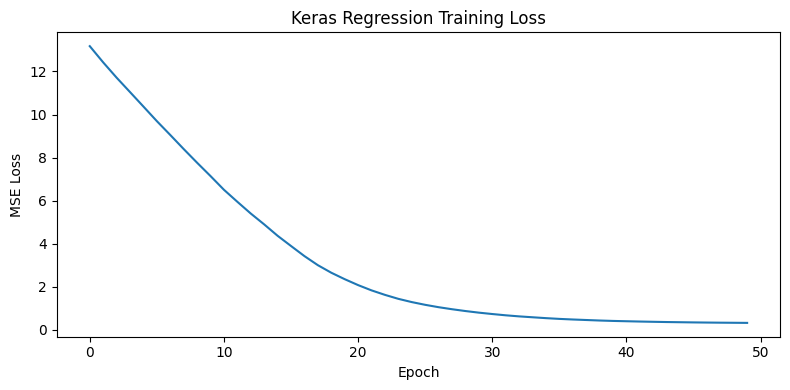

In [9]:
# Plot training loss curve.
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Keras Regression Training Loss")
plt.tight_layout()

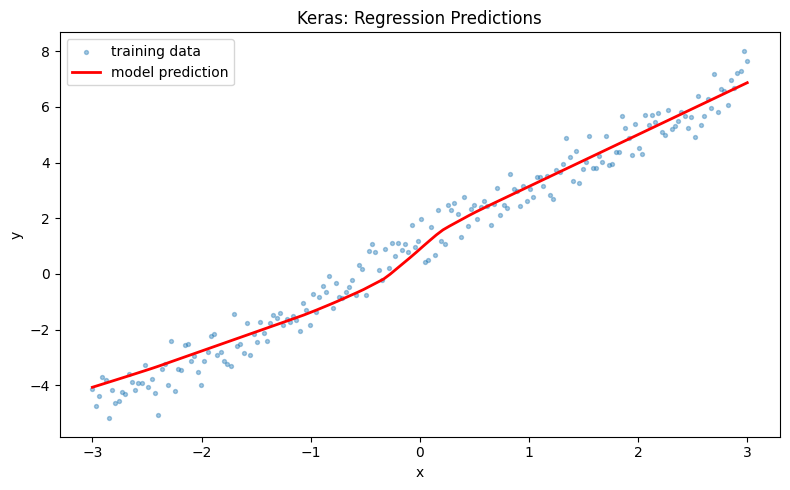

In [10]:
# Plot predictions vs ground truth.
X_test = np.linspace(-3, 3, 100).reshape(-1, 1).astype(np.float32)
y_pred = model.predict(X_test, verbose=0)
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, s=8, alpha=0.4, label="training data")
plt.plot(X_test, y_pred, color="red", lw=2, label="model prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Keras: Regression Predictions")
plt.legend()
plt.tight_layout()

## 4. TensorFlow Probability: Distributions

TensorFlow Probability (TFP) adds probabilistic programming on top of
TensorFlow. The core primitive is a **Distribution** — an object that can
sample values and evaluate log-probabilities.

Common distributions:
| Class | Parameters | Use case |
|---|---|---|
| `Normal` | `loc`, `scale` | Continuous data, measurement noise |
| `Bernoulli` | `probs` | Binary outcomes |
| `Poisson` | `rate` | Count data |
| `Beta` | `concentration1/0` | Probabilities (0-1) |

In [11]:
# Normal distribution: sample and evaluate PDF.
normal = tfp.distributions.Normal(loc=0.0, scale=1.0)
samples = normal.sample(1000).numpy()
log_prob = normal.log_prob(0.0).numpy()
_LOG.info(
    "Sampled %d values, mean=%.3f, std=%.3f",
    len(samples),
    samples.mean(),
    samples.std(),
)
_LOG.info("log p(x=0) = %.4f", log_prob)

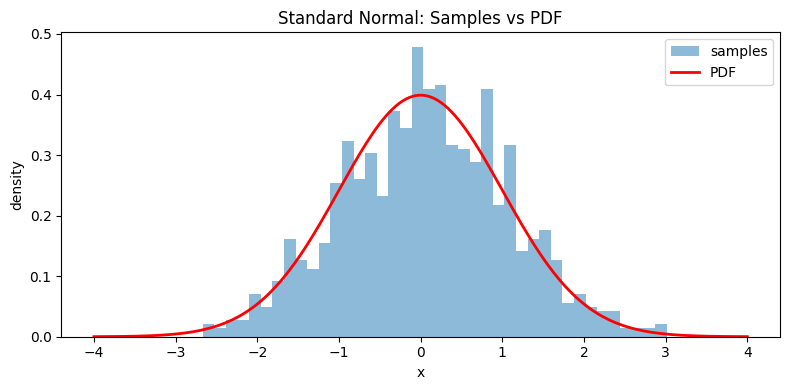

In [12]:
# Plot the standard normal PDF alongside histogram of samples.
x_vals = np.linspace(-4, 4, 200)
pdf_vals = normal.prob(x_vals).numpy()
plt.figure(figsize=(8, 4))
plt.hist(samples, bins=40, density=True, alpha=0.5, label="samples")
plt.plot(x_vals, pdf_vals, lw=2, color="red", label="PDF")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Standard Normal: Samples vs PDF")
plt.legend()
plt.tight_layout()

## 5. TFP: Bayesian Inference with Variational Inference

Variational Inference (VI) approximates an intractable posterior
`p(z | x)` with a simpler distribution `q(z)` by maximising the
Evidence Lower Bound (ELBO).

Here we estimate the mean and variance of a Gaussian from data using VI.

In [13]:
# True parameters.
TRUE_MEAN = 5.0
TRUE_STD = 2.0
np.random.seed(42)
data = np.random.normal(TRUE_MEAN, TRUE_STD, 300).astype(np.float32)
_LOG.info("Data: mean=%.2f, std=%.2f", data.mean(), data.std())

In [14]:
# Variational parameters (learnable).
q_mean = tf.Variable(0.0, name="q_mean")
# Parameterise std as log to keep it positive.
q_log_std = tf.Variable(0.0, name="q_log_std")

optimizer = tf_keras.optimizers.Adam(learning_rate=0.05)

losses = []
for step in range(300):
    with tf.GradientTape() as tape:
        q_std = tf.exp(q_log_std)
        q = tfp.distributions.Normal(loc=q_mean, scale=q_std)
        # ELBO = E_q[log p(data | z)] - KL(q || prior).
        log_likelihood = tf.reduce_sum(
            tfp.distributions.Normal(loc=q_mean, scale=TRUE_STD).log_prob(data)
        )
        prior = tfp.distributions.Normal(loc=0.0, scale=10.0)
        kl = tfp.distributions.kl_divergence(q, prior)
        loss = -(log_likelihood - kl)
    grads = tape.gradient(loss, [q_mean, q_log_std])
    optimizer.apply_gradients(zip(grads, [q_mean, q_log_std]))
    losses.append(loss.numpy())

_LOG.info(
    "Estimated mean=%.3f (true=%.1f), std=%.3f (true=%.1f)",
    q_mean.numpy(),
    TRUE_MEAN,
    tf.exp(q_log_std).numpy(),
    TRUE_STD,
)

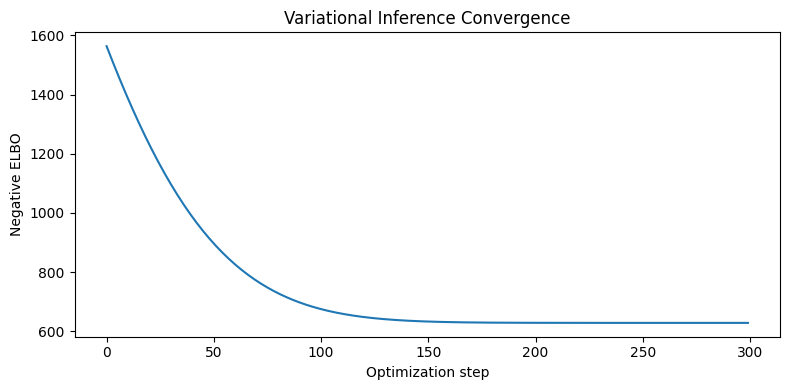

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Optimization step")
plt.ylabel("Negative ELBO")
plt.title("Variational Inference Convergence")
plt.tight_layout()

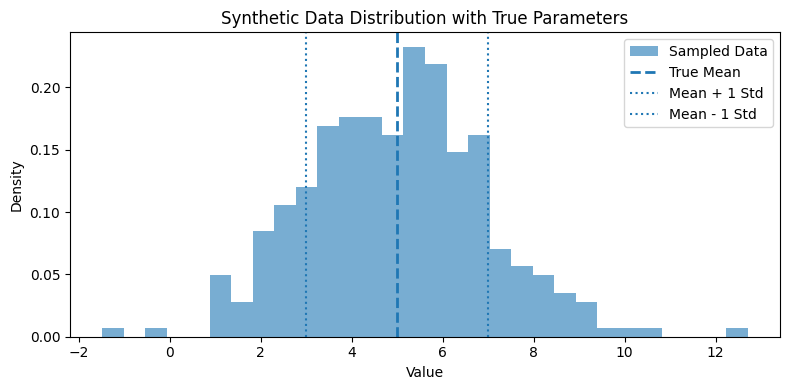

In [16]:
# Visualize generated data and true parameters
plt.figure(figsize=(8, 4))

plt.hist(data, bins=30, density=True, alpha=0.6, label="Sampled Data")

# True mean line
plt.axvline(TRUE_MEAN, linestyle="--", linewidth=2, label="True Mean")

# True mean ± std
plt.axvline(TRUE_MEAN + TRUE_STD, linestyle=":", label="Mean + 1 Std")
plt.axvline(TRUE_MEAN - TRUE_STD, linestyle=":", label="Mean - 1 Std")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Synthetic Data Distribution with True Parameters")
plt.legend()
plt.tight_layout()

# Decomposing the Past, Forecasting the Future

In [17]:
tfd = tfp.distributions
sts = tfp.sts

np.random.seed(42)
num_steps = 150

trend      = np.linspace(0, 5, num_steps)
seasonality = np.sin(np.linspace(0, 6 * np.pi, num_steps))  # ~3 weekly cycles
noise       = np.random.normal(0, 0.3, num_steps)

observed = (trend + seasonality + noise).astype(np.float32)
observed_tensor = tf.constant(observed[:, np.newaxis])  # shape [T, 1]

### 1. Build STS

In [18]:
trend_component = sts.LocalLinearTrend(observed_time_series=observed_tensor)

seasonal_component = sts.Seasonal(
    num_seasons=7,
    observed_time_series=observed_tensor,
    name='day_of_week'
)

model = sts.Sum(
    components=[trend_component, seasonal_component],
    observed_time_series=observed_tensor
)

### 2. Variational Inference

2026-03-10 16:28:33.083803: I external/local_xla/xla/service/service.cc:163] XLA service 0x59c66d6d6a70 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-03-10 16:28:33.083815: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
2026-03-10 16:28:33.181092: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-10 16:28:33.203540: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:108] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. fit_surrogate_posterior/StatefulPartitionedCall/monte_carlo_variational_loss/split_seed/sanitize_seed/seed


I0000 00:00:1773160116.068527       8 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


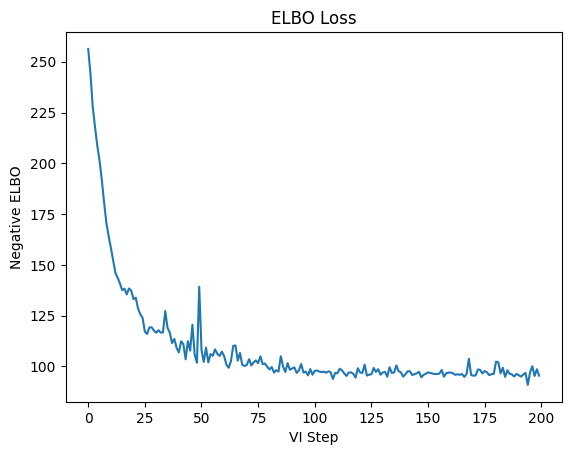

In [19]:
# Build surrogate posterior and run VI
surrogate_posterior = tfp.sts.build_factored_surrogate_posterior(model=model)

num_variational_steps = 200
optimizer = tf.optimizers.Adam(learning_rate=0.1)

@tf.function(experimental_compile=True)
def run_vi():
    return tfp.vi.fit_surrogate_posterior(
        target_log_prob_fn=model.joint_distribution(observed_tensor).log_prob,
        surrogate_posterior=surrogate_posterior,
        optimizer=optimizer,
        num_steps=num_variational_steps
    )

losses = run_vi()
plt.plot(losses)
plt.title("ELBO Loss")
plt.xlabel("VI Step")
plt.ylabel("Negative ELBO")
plt.show()

### 3. Component Decomposition - `tfp.sts.decompose_by_component`

Once the model is fitted, we can ask: *how much did each component contribute to the observed signal at every timestep?*

`decompose_by_component` runs a Kalman smoother using samples drawn from the fitted posterior, and returns a distribution over each component's latent trajectory. The result is a dictionary mapping each component to a `tfd.Distribution`, where:
- `.mean()` gives the expected contribution of that component at each timestep
- `.stddev()` gives the uncertainty around that estimate

The shaded bands in the plot reflect posterior uncertainty - a wider band means the model is less certain about that component's individual contribution.

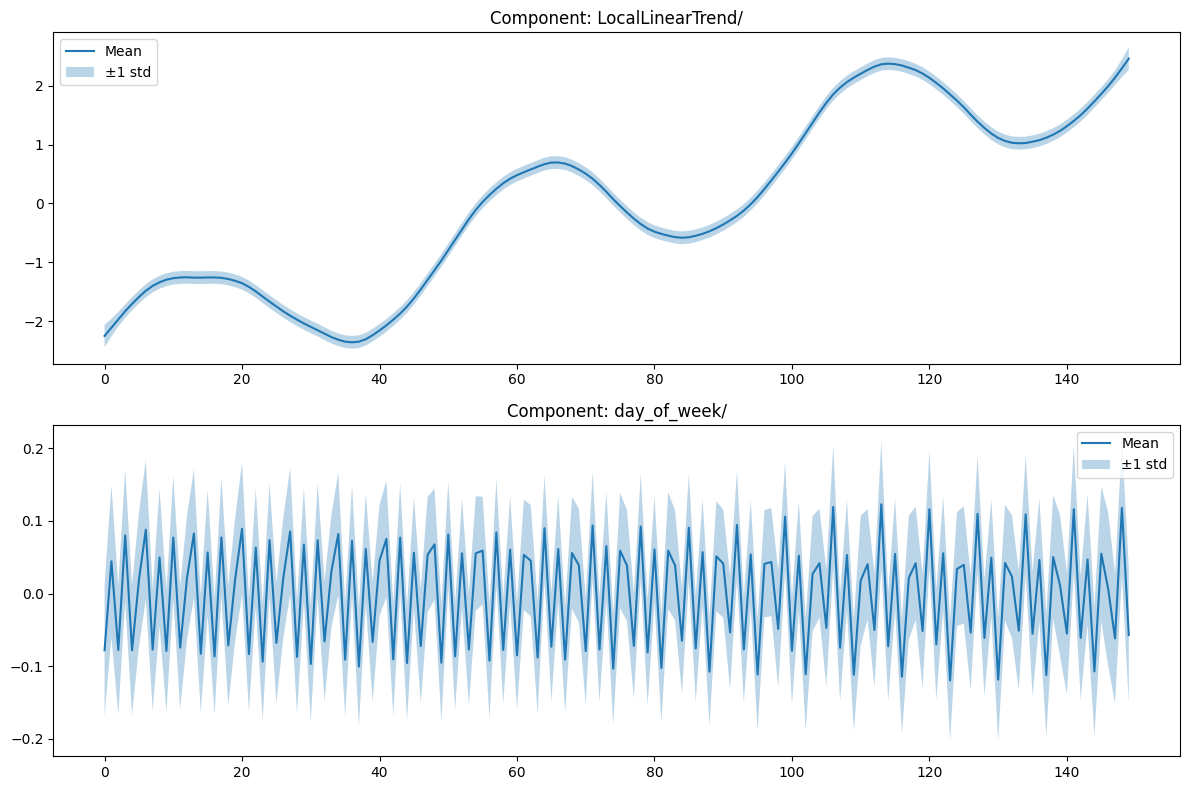

In [20]:
# Draw samples from the fitted posterior
posterior_samples = surrogate_posterior.sample(50)

# Decompose the observed series into per-component contributions
component_dists = sts.decompose_by_component(
    model=model,
    observed_time_series=observed_tensor,
    parameter_samples=posterior_samples
)

# Plot each component's mean ± 1 std
fig, axes = plt.subplots(len(component_dists), 1, figsize=(12, 4 * len(component_dists)))

for ax, (component, dist) in zip(axes, component_dists.items()):
    mean = dist.mean().numpy().squeeze()   # shape [T]
    std  = dist.stddev().numpy().squeeze()
    ax.plot(mean, label='Mean')
    ax.fill_between(range(len(mean)), mean - std, mean + std, alpha=0.3, label='±1 std')
    ax.set_title(f'Component: {component.name}')
    ax.legend()

plt.tight_layout()
plt.show()

### 4. Forecasting — `tfp.sts.forecast`

With the model fitted on observed data, we can now extrapolate forward in time.

`tfp.sts.forecast` runs a Kalman filter through the observed series to capture the final latent state, then propagates it forward for `num_steps_forecast` steps using the model's transition dynamics. Uncertainty in the fitted parameters (via `parameter_samples`) flows directly into the forecast, giving us a full distribution over future values rather than just a point estimate:
- `.mean()` is the point forecast
- `.stddev()` is the spread, which naturally grows the further out we predict

The widening uncertainty band over the forecast horizon is expected — the model becomes honestly less confident the further it looks ahead.

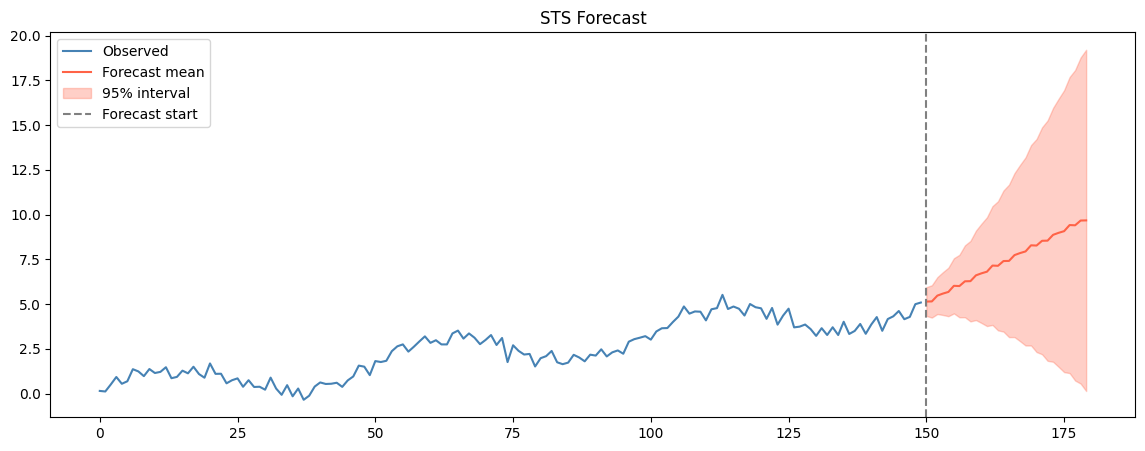

In [21]:
num_steps_forecast = 30

forecast_dist = sts.forecast(
    model=model,
    observed_time_series=observed_tensor,
    parameter_samples=posterior_samples,
    num_steps_forecast=num_steps_forecast
)

forecast_mean = forecast_dist.mean().numpy().squeeze()     # shape [num_steps_forecast]
forecast_std  = forecast_dist.stddev().numpy().squeeze()

# Plot observed + forecast
plt.figure(figsize=(14, 5))
t_obs      = np.arange(num_steps)
t_forecast = np.arange(num_steps, num_steps + num_steps_forecast)

plt.plot(t_obs, observed, label='Observed', color='steelblue')
plt.plot(t_forecast, forecast_mean, label='Forecast mean', color='tomato')
plt.fill_between(
    t_forecast,
    forecast_mean - 2 * forecast_std,
    forecast_mean + 2 * forecast_std,
    alpha=0.3, color='tomato', label='95% interval'
)
plt.axvline(num_steps, linestyle='--', color='gray', label='Forecast start')
plt.title("STS Forecast")
plt.legend()
plt.show()